# Do Bull Markets Die of Old Age? 🐂
### "This bull market is long in the tooth" — checked against 92 years and a few thousand fake markets

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

Every long rally ends with the same headline: *the bull is getting old*. It sounds like common
sense — things that have lived a long time are closer to the end. We dated every US bull market
since 1926 and asked whether an old bull really is more likely to die next month than a young one.
It isn't — and the reason it *looks* like it is turns out to be the ruler, not the market.

> 📓 **This is the plain-language layer.** The duration model, the two null worlds, the
> predictive regressions and the bootstraps are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Beat 0 · Verdict (real tape).** The badges and the numbers quoted in the text come from the
> pinned run in [`docs/results.md`](../docs/results.md) (as-of 2022-11-30). The charts below are
> drawn live from the same bundled tapes.
>
> ⚠️ **Not investment advice.** Research and education only.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.0)
plt.rcParams["figure.dpi"] = 80
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
from oldage import data, strategy as st

## The answer first 🎯

| Question | Answer |
|---|---|
| Do older bulls end more often? | Not more than you'd expect from chance. |
| Why does it *look* like they do? | The 20% rule can't kill a baby bull — so *any* market looks like it ages. |
| Does an old bull warn of a bad year ahead? | No: t = -0.99. |
| Should you sell half when the bull gets old? | It cost you **6.2×** your final wealth since 1940. |

> **In one sentence:** Bull markets only look like they die of old age (Weibull k = 1.10) because a ±20% ruler builds ageing into any series — random walks dated the same way age at least as fast (p = 0.72), bull age does not forecast next year's return (t = −0.99), and selling half of every old bull ended with 6.2× less money than buy-and-hold.

## 1 · The claim

"Long in the tooth", "late cycle", "on borrowed time". The belief has a precise shape: the
**older** a bull market is, the **more likely** it is to end soon. If that's true, the age of the
current bull is a free risk signal — and a sensible investor trims stocks once a bull has outlived
the typical one.

It's the same idea economists once had about business expansions ("they die of old age"), and
which they tested, carefully, decades ago. We run that test on the stock market.

In [2]:
ff = data.load_ff_monthly()                    # Fama-French market, TOTAL return, monthly
sp = data.load_sp500_daily()                   # S&P 500 PRICE index, daily (no dividends)
lv = data.total_return_index(ff["mkt"])
print(f"FF monthly total return {ff.index[0]:%Y-%m} → {ff.index[-1]:%Y-%m}  "
      f"fingerprint {data.fingerprint(ff)}")
print(f"S&P 500 daily price     {sp.index[0]:%Y-%m-%d} → {sp.index[-1]:%Y-%m-%d}  "
      f"fingerprint {data.fingerprint(sp)}")

FF monthly total return 1926-07 → 2018-11  fingerprint 394be76d78ac
S&P 500 daily price     1990-01-02 → 2022-11-30  fingerprint e223c581ae22


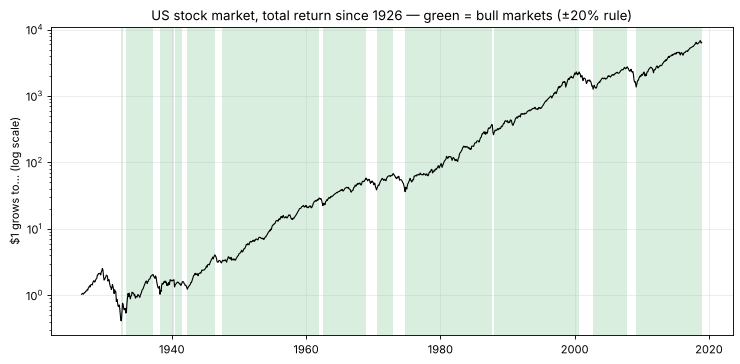

  start     end  months  gain  censored
1932-06 1932-08       2 0.835     False
1933-02 1937-02      48 2.796     False
1938-03 1940-04      25 0.649     False
1940-05 1941-07      14 0.202     False
1942-04 1946-05      49 2.289     False
1947-05 1961-12     175 8.432     False
1962-06 1968-11      77 1.602     False
1970-06 1972-12      30 0.757     False
1974-09 1987-08     155 9.251     False
1987-11 2000-08     153 7.834     False
2002-09 2007-10      61 1.172     False
2009-02 2018-11     117 3.685      True


In [3]:
cy = st.date_cycles(lv, 0.20)
fig, ax = plt.subplots(figsize=(11, 5))
ax.semilogy(lv.index, lv, color="k", lw=1)
for r in cy[cy.phase == "bull"].itertuples():
    ax.axvspan(r.start, r.end, color="#2ea44f", alpha=0.18, lw=0)
ax.set_title("US stock market, total return since 1926 — green = bull markets (±20% rule)")
ax.set_ylabel("$1 grows to… (log scale)")
plt.show()
b = cy[cy.phase == "bull"]
print(b[["start", "end", "duration", "amplitude", "censored"]]
      .assign(start=lambda d: d.start.dt.strftime("%Y-%m"), end=lambda d: d.end.dt.strftime("%Y-%m"))
      .rename(columns={"duration": "months", "amplitude": "gain"}).to_string(index=False))

That's the entire sample: **11 completed bull markets** in 92 years (plus
the one still running when the data stop in 2018). Every number below rests on those few.
Twelve is not a lot — keep that in mind; we'll come back to it.

## 2 · So what?

If old bulls really were fragile, you would want to own fewer stocks late in a long rally and more
early on — a simple, cheap rule that, if it worked, would improve almost anyone's portfolio. And it
would mean markets have a *clock* in them: that the passage of time itself, not news, wears a rally
out.

## 3 · How we'd know

A rough way to check: line up all bull markets by age and ask, at each age, what share of the bulls
still alive ended within the next year. If old bulls are fragile, that share should climb with age.

**The catch we set up in advance:** the 20% rule itself bends that curve. A bull can't even be
*called* a bull until prices are 20% off the bottom, and can't end until they're 20% off the top.
So very young bulls almost never "die", and any series dated this way — even a coin-flipping random
walk — will look like it ages. The fair comparison is therefore not *"is the curve rising?"* but
*"is it rising **faster** than for fake markets with no memory at all?"* If real bulls age like fake
ones, the claim is a **mirage of the ruler**.

## 4 · The teardown

### 4.1 · How long do bulls live?

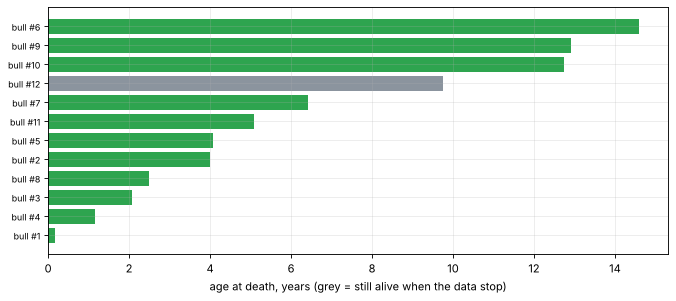

median completed bull: 49 months; shortest 2, longest 175


In [4]:
d, c = st.bull_durations(lv, 0.20)
fig, ax = plt.subplots(figsize=(10, 4))
order = np.argsort(d)
ax.barh(range(len(d)), d[order] / 12, color=["#8b949e" if cc else "#2ea44f" for cc in c[order]])
ax.set_yticks(range(len(d)))
ax.set_yticklabels([f"bull #{i+1}" for i in order], fontsize=8)
ax.set_xlabel("age at death, years (grey = still alive when the data stop)")
plt.show()
print(f"median completed bull: {np.median(d[~c]):.0f} months; shortest {d.min():.0f}, longest {d.max():.0f}")

Some bulls last two months; some last fourteen years. Wide spread, few data points.

### 4.2 · The ruler trick, shown

Here is a market we *made up*: a pure random walk with the same average return and the same
month-to-month swings as the real thing. It has no memory, by construction — last month tells you
nothing about next month, and certainly nothing about "age". We date it with the same 20% rule.

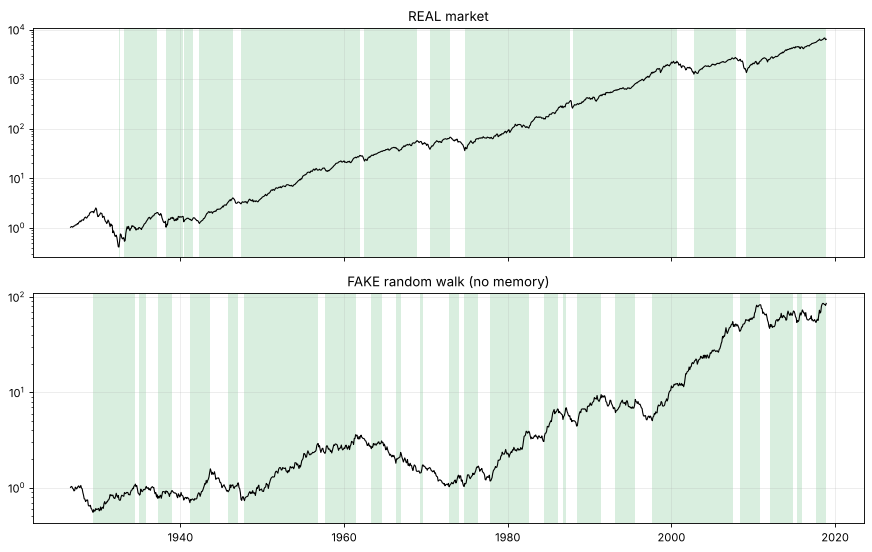

In [5]:
lr = np.log1p(ff["mkt"])
fake = st.simulate_log_returns("rw", len(lr), 1, {"mu": lr.mean(), "sigma": lr.std()}, seed=7)[0]
fake_lv = pd.Series(np.exp(np.cumsum(fake)), index=ff.index)
fcy = st.date_cycles(fake_lv, 0.20)
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
for ax, s, cc, ttl in ((axes[0], lv, cy, "REAL market"), (axes[1], fake_lv, fcy, "FAKE random walk (no memory)")):
    ax.semilogy(s.index, s, color="k", lw=1)
    for r in cc[cc.phase == "bull"].itertuples():
        ax.axvspan(r.start, r.end, color="#2ea44f", alpha=0.18, lw=0)
    ax.set_title(ttl)
plt.tight_layout(); plt.show()

Could you tell which one is real without the labels? The fake one has bull markets and bear
markets too — long ones, short ones, crashes. The "cycle" is something the dating rule finds in
any wiggly line that drifts up.

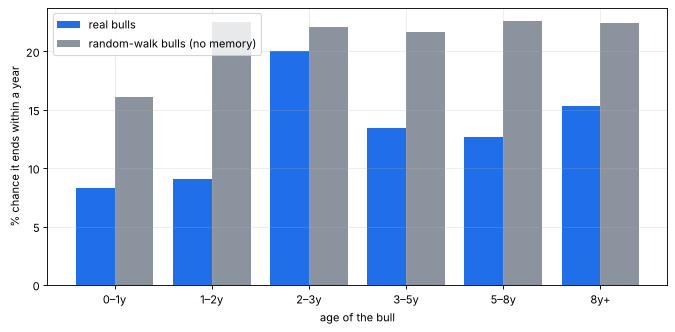

In [6]:
res = st.duration_test(ff["mkt"], 0.20, n_sims=200, n_boot=300, rf=ff["rf"])
real_lt = res["life"]["annual_hazard"]
rw_lt = res["nulls"]["rw"]["life"]["annual_hazard"]
x = np.arange(len(real_lt))
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(x - 0.2, real_lt * 100, 0.4, color="#1f6feb", label="real bulls")
ax.bar(x + 0.2, rw_lt * 100, 0.4, color="#8b949e", label="random-walk bulls (no memory)")
ax.set_xticks(x); ax.set_xticklabels(real_lt.index)
ax.set_xlabel("age of the bull"); ax.set_ylabel("% chance it ends within a year")
ax.legend(); plt.show()

The blue bars are what believers point at: real bulls ended **8%** of the time in their
first year and about twice that by year three. But look at the grey bars — the memoryless fake
market *also* shows a low first year, because the rule can't kill a baby bull. After year three
the real hazard doesn't keep climbing; it flattens around 13–15% a year. **Old bulls are not
fragile; young bulls are just hard to date.**

> 🔬 **For the quants.** A Weibull duration model gives the real bulls a shape
> k = 1.10; random walks dated the same way give a median k = 1.22
> (88% of them above 1). One-sided p = 0.72 against the random
> walk, 0.24 against a GARCH world. A naive test of "k = 1" calls a memoryless
> random walk "dies of old age" 18% of the time.

### 4.3 · Does an old bull warn of a bad year?

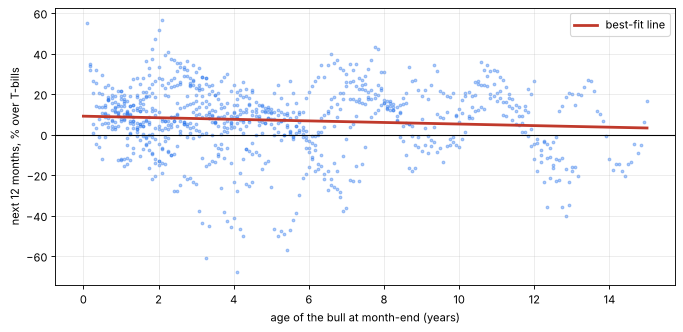

slope: -0.39% per year of age, t = -0.99


In [7]:
rt = st.realtime_state(lv, 0.20)          # what you could have known at each month-end
fwd = st.forward_log_return(ff["mkt"], ff["rf"], 12)
m = (rt.state == 1) & rt.age.notna() & fwd.notna()
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.scatter(rt.age[m] / 12, fwd[m] * 100, s=6, alpha=0.35, color="#1f6feb")
pr = st.predictive_regression(ff["mkt"], ff["rf"])
xs = np.linspace(0, (rt.age[m] / 12).max(), 50)
ax.plot(xs, (pr["alpha"] + pr["slope"] * xs) * 100, color="#c0392b", lw=2.5, label="best-fit line")
ax.axhline(0, color="k", lw=1)
ax.set_xlabel("age of the bull at month-end (years)"); ax.set_ylabel("next 12 months, % over T-bills")
ax.legend(); plt.show()
print(f"slope: {pr['slope']:+.2%} per year of age, t = {pr['t']:+.2f}")

A cloud with a line through it that is very nearly flat. A bull that is ten years old has been
followed by roughly the same next year as a bull that is two.

## 5 · The verdict

**Signal: None.** Real bull markets age no faster than the bulls of a random walk dated
with the same ruler (p = 0.72), and a bull's age does not predict the next year's
return (t = -0.99) or drawdown. The "long in the tooth" pattern is real *in the chart* —
it's produced by how we draw the chart.

## 6 · Could you trade it?

The believers' rule: hold 100% stocks, drop to 50% (rest in T-bills) once the current bull is older
than the typical one — judged only on what was known at the time, acting a month later, paying
costs.

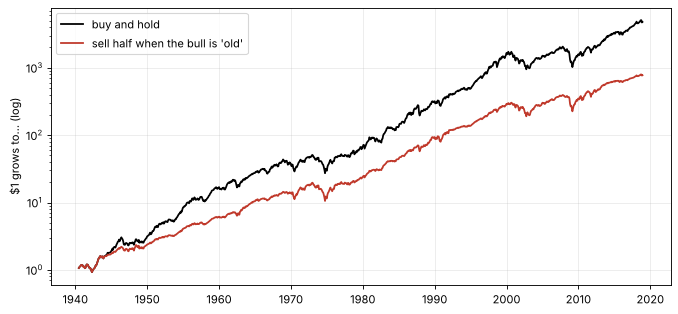

since 1940-05: $1 → $4,787 buy-and-hold vs $773 with the rule


In [8]:
W = st.age_rule_weights(lv, 0.20)
start = W.median_age.first_valid_index()
bt = st.age_rule_backtest(ff["mkt"], ff["rf"], W.weight, 10.0)
bt = bt[bt.index > start]
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.semilogy((1 + bt.bh).cumprod(), color="k", lw=1.6, label="buy and hold")
ax.semilogy((1 + bt.net).cumprod(), color="#c0392b", lw=1.6, label="sell half when the bull is 'old'")
ax.set_ylabel("$1 grows to… (log)"); ax.legend(); plt.show()
s = st.summarize_backtest(bt)
print(f"since {start:%Y-%m}: $1 → ${s['tw_bh']:,.0f} buy-and-hold vs ${s['tw_net']:,.0f} with the rule")

**Tradability: Mirage.** The rule spent 59% of the months half in cash,
mostly during long bulls that kept going, and was fully invested exactly when the market was in
its rough patches. Even per unit of risk it lost (Sharpe 0.49 vs
0.57), and it also lost on the separate S&P 500 daily tape since 1990.

## 7 · Going further 🚪

- **Twelve bulls is the hard ceiling.** No method squeezes certainty out of a dozen events — the
  honest conclusion is "no evidence of ageing beyond the ruler", not "proven memoryless".
- **What *might* age is valuation, not time.** Long bulls tend to end expensive; whether *price*
  rather than *age* predicts the end is a different study (and the desk has several on valuation).
- **Try other rulers.** The quants notebook reruns everything at 15%, 25% and an asymmetric rule.
  A business-cycle-style dating algorithm (Pagan–Sossounov) is a natural fork.
- **The general lesson:** whenever a pattern is found by a rule that *defines* the events, check
  what the rule finds in data that has no pattern at all.